# Optuna Studies Analysis

This notebook plots the results of the Optuna studies.

## Setup

In [124]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import optuna
from scipy.stats import gaussian_kde

plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "figure.dpi": 300,
})

LAUNCH_DIR = Path("../out/flat_conv_full")
PLOTS_DIR = LAUNCH_DIR / "plots"

PLOTS_DIR.mkdir(exist_ok=True)

In [125]:
studies_files = sorted([f.name for f in LAUNCH_DIR.iterdir() if f.is_file() and f.suffix == ".sqlite"])
studies = [
    optuna.load_study(study_name=study.split(".")[0], storage=f"sqlite:///{LAUNCH_DIR / study}").trials_dataframe()
    for study in studies_files
]

In [126]:
studies[0].head()

,number,value,datetime_start,datetime_complete,duration,params_batch_size_exp,params_conv_layers_spec,params_fusion_dropout,params_kl_max,params_lr,params_n_fusion_layers,user_attrs_accuracies,user_attrs_accuracy_p25,user_attrs_accuracy_p75,state
0,0,0.875000,2026-03-27 10:28:49.442788,2026-03-27 10:43:02.134238,0 days 00:14:12.691450,7,0,0.2,17.254717,0.003575,3,"{'1543783956': 0.8229166666666666, '1735184881...",0.830729,0.914583,COMPLETE
1,1,0.881250,2026-03-27 10:43:02.271409,2026-03-27 10:57:45.397458,0 days 00:14:43.126049,5,0,0.3,8.341106,0.007725,1,"{'1275403490': 0.8479166666666667, '1825033855...",0.840104,0.904167,COMPLETE
2,2,0.903125,2026-03-27 10:57:45.529101,2026-03-27 11:10:28.044614,0 days 00:12:42.515513,6,0,0.1,4.816415,0.002815,2,"{'1543783956': 0.8979166666666667, '4921539': ...",0.882292,0.927604,COMPLETE
3,3,0.881250,2026-03-27 11:10:28.160450,2026-03-27 11:24:41.525849,0 days 00:14:13.365399,5,2,0.2,10.508421,0.004717,1,"{'4921539': 0.9166666666666666, '1825033855': ...",0.867188,0.918750,COMPLETE
4,4,0.842708,2026-03-27 11:24:41.645538,2026-03-27 11:38:54.636556,0 days 00:14:12.991018,6,2,0.3,17.160445,0.001248,3,"{'1275403490': 0.8229166666666666, '1543783956...",0.811458,0.883333,COMPLETE



## Plots

### Trial Outcomes

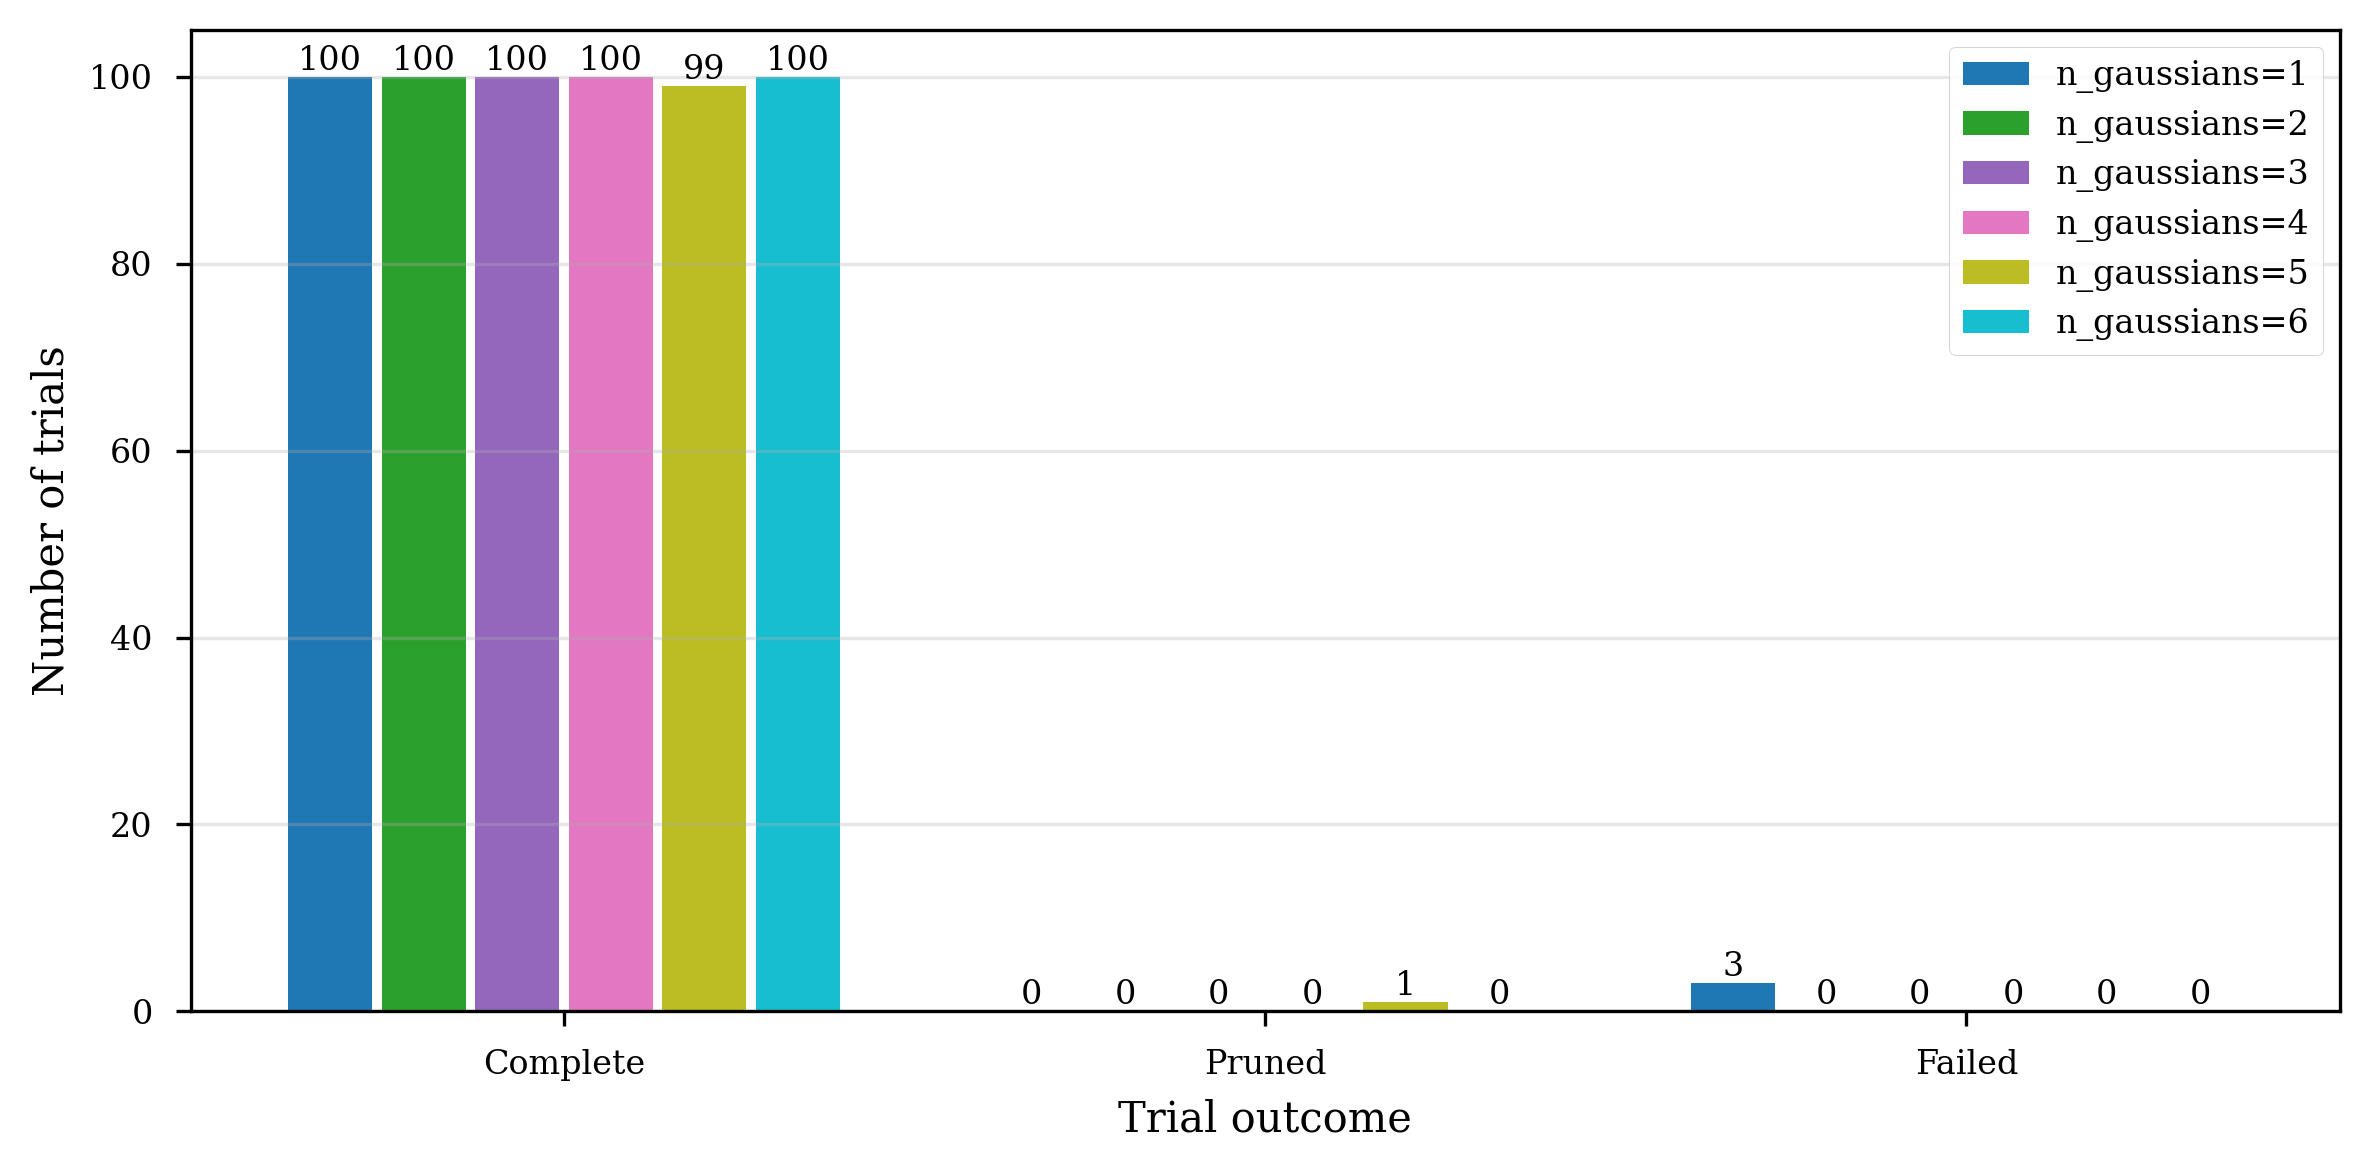

In [127]:
outcome_states = ["COMPLETE", "PRUNED", "FAIL"]
outcome_labels = ["Complete", "Pruned", "Failed"]

x = np.arange(len(outcome_labels))
width = 0.8 / len(studies)

plt.figure(figsize=(8, 4))

colors = plt.colormaps["tab10"](np.linspace(0, 1, len(studies)))
study_labels = [f"n_gaussians={i+1}" for i in range(len(studies))]

for i, study in enumerate(studies):
    counts = [(study["state"] == state).sum() for state in outcome_states]
    positions = x + (i - (len(studies) - 1) / 2) * width

    bars = plt.bar(
        positions,
        counts,
        width=width * 0.9,
        color=colors[i],
        label=study_labels[i],
    )

    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

plt.xticks(x, outcome_labels)
plt.xlabel("Trial outcome")
plt.ylabel("Number of trials")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "trial_outcomes_gaussians_all.pdf")
plt.show()

### Accuracy Distribution

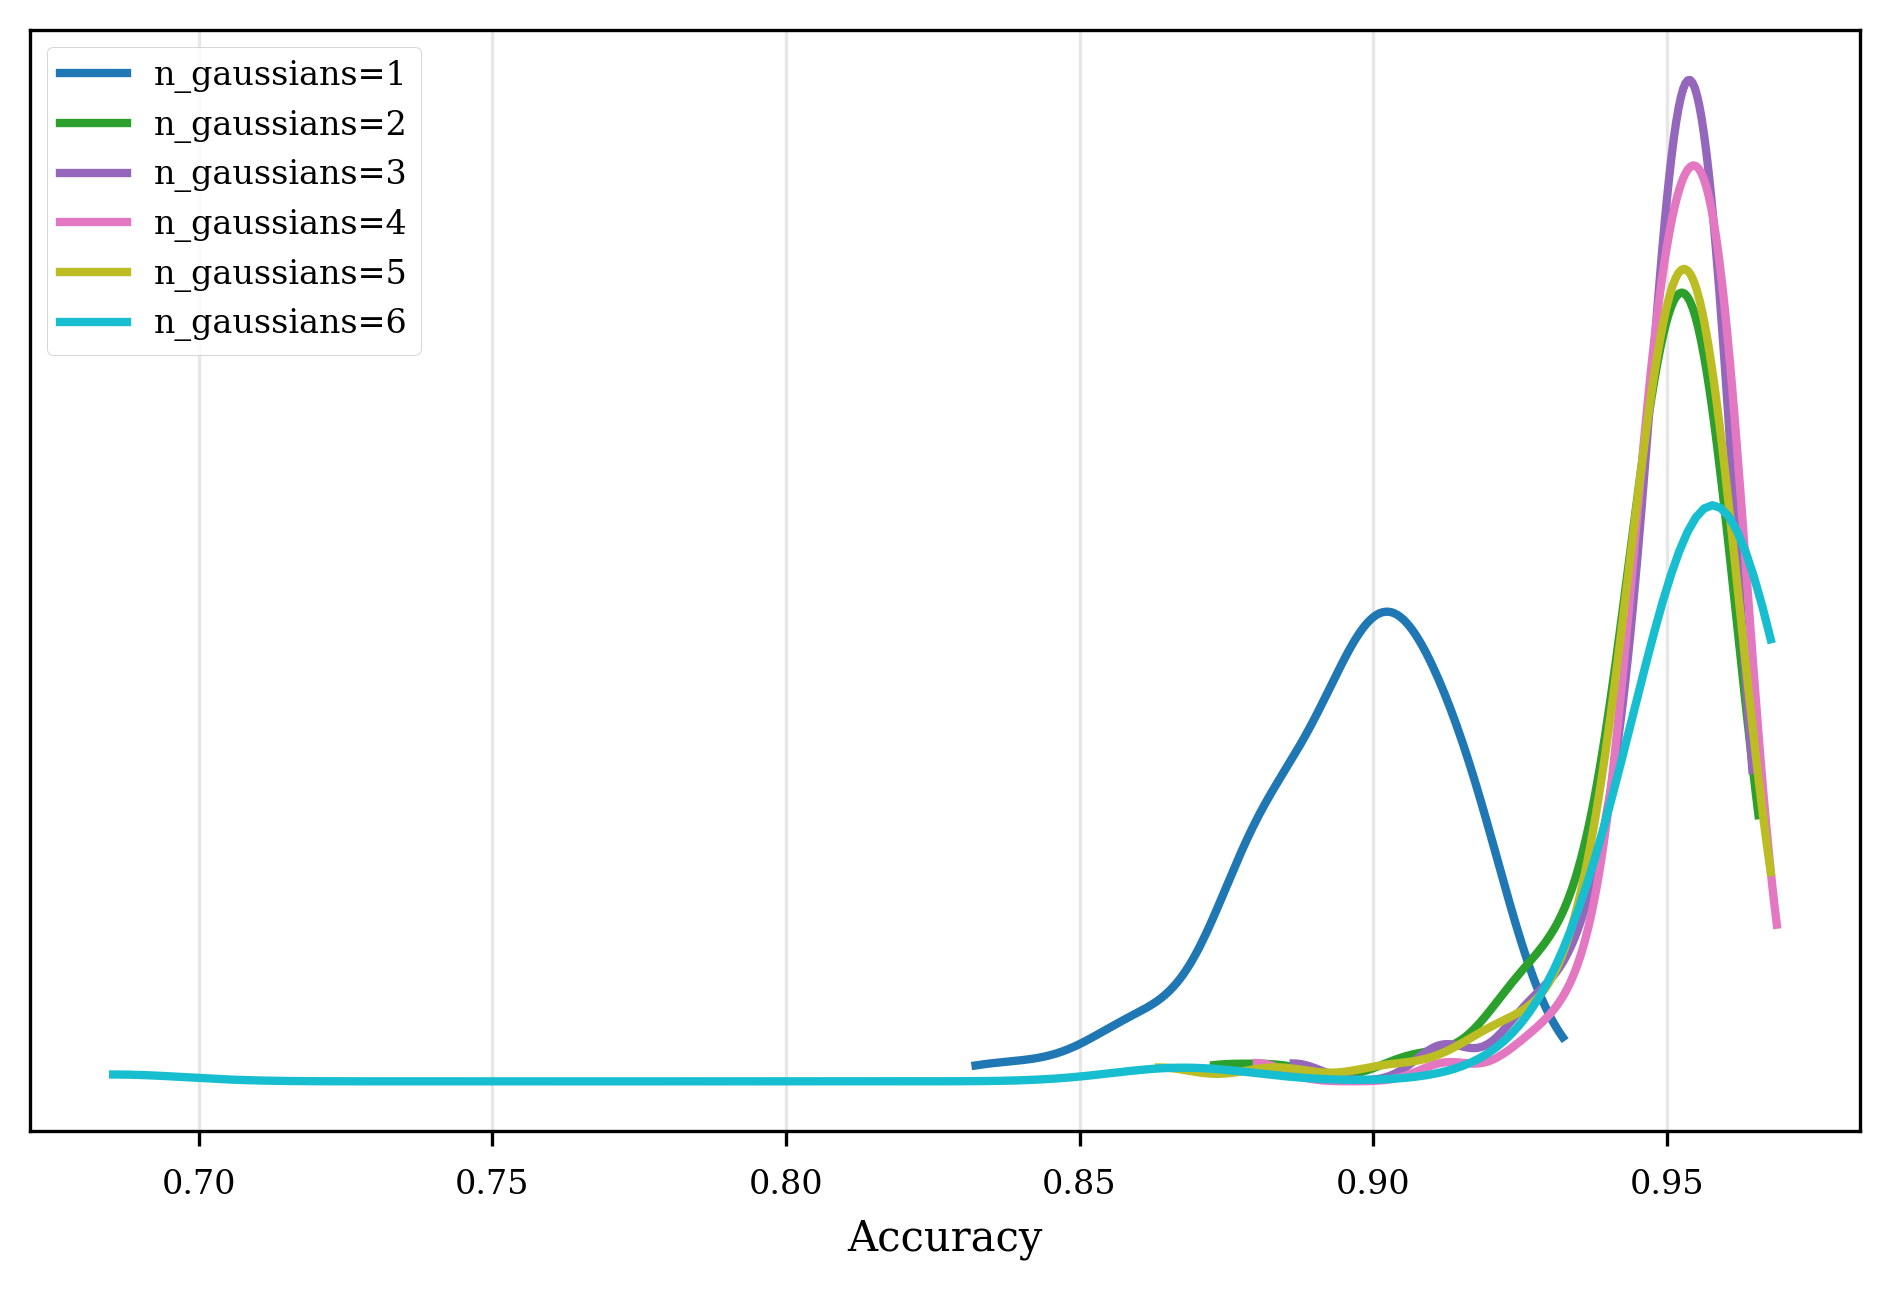

In [128]:
colors = plt.colormaps["tab10"](np.linspace(0, 1, len(studies)))

for i, study in enumerate(studies):
    completed = study[study["state"] == "COMPLETE"]["value"].copy().dropna()
    kde = gaussian_kde(completed)
    x = np.linspace(completed.min(), completed.max(), 200)
    plt.plot(x, kde(x), linewidth=2, label=f"n_gaussians={i+1}", color=colors[i])

plt.xlabel("Accuracy")
plt.yticks([])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "accuracy_kde_gaussians_all.pdf")
plt.show()

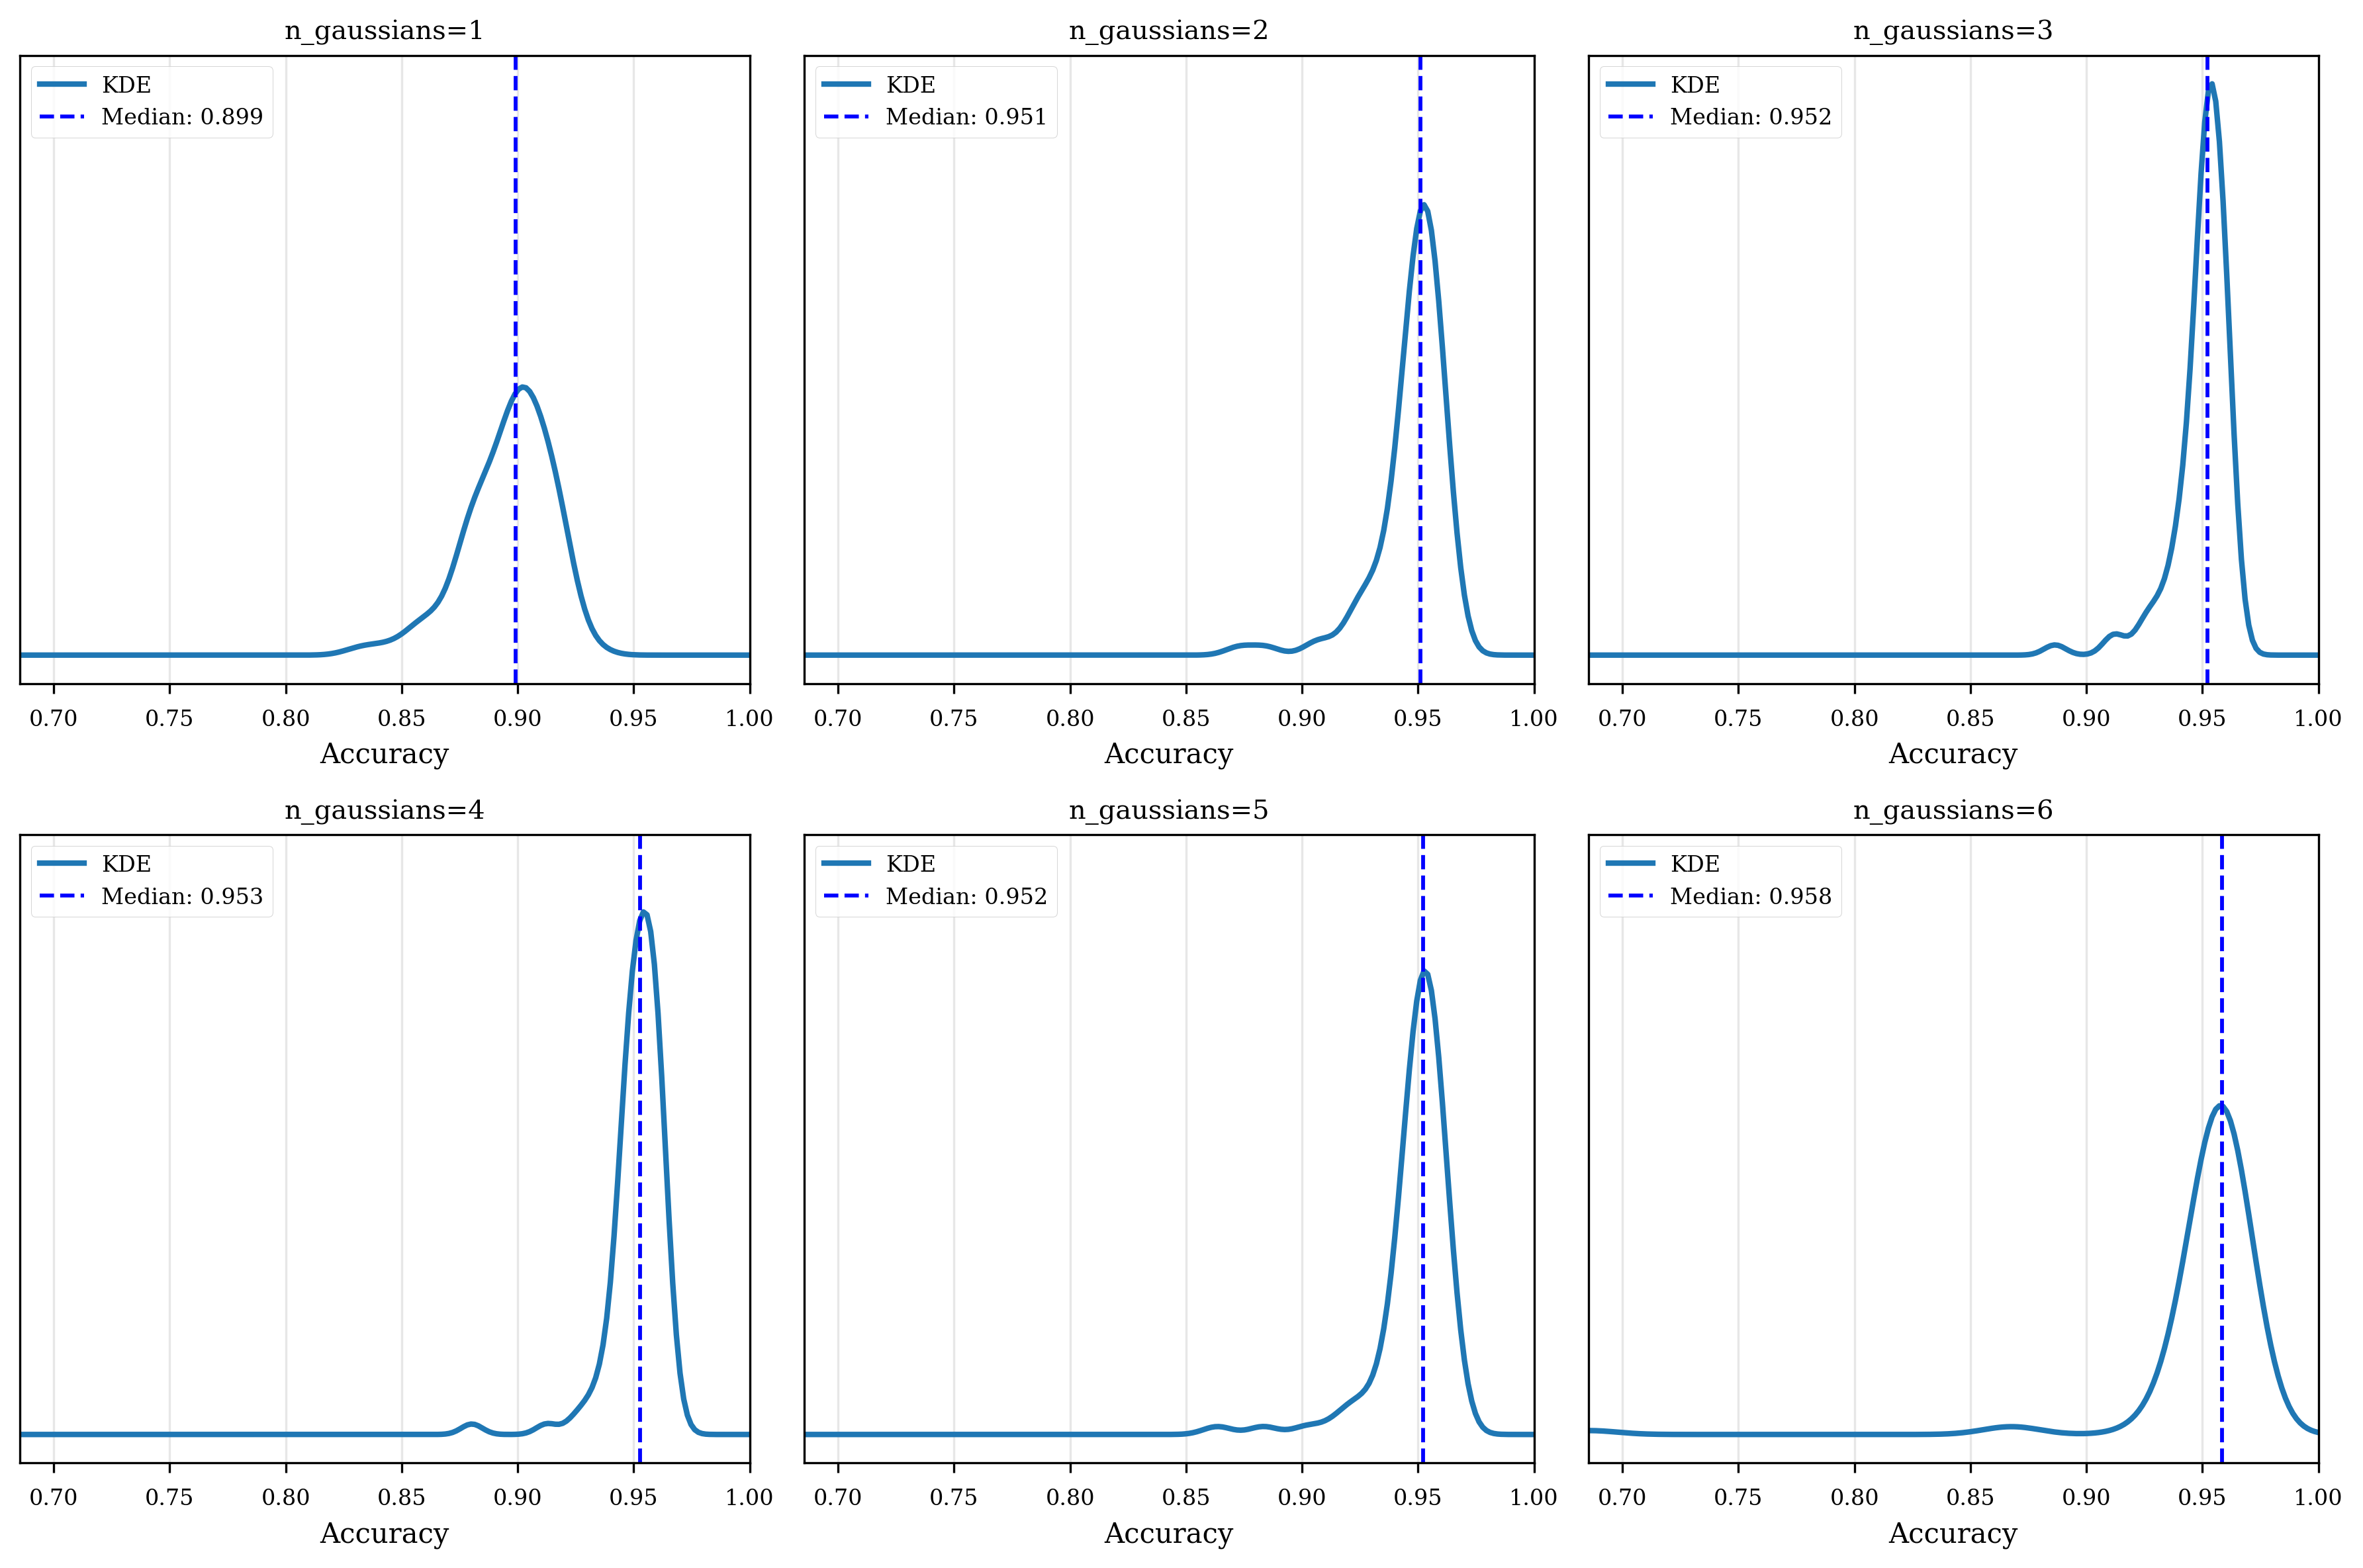

In [129]:
all_completed = [study.loc[study["state"] == "COMPLETE"] for study in studies]

x_min = min(c["value"].min() for c in all_completed)
x_max = 1
x_range = np.linspace(x_min, x_max, 200)

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharey=True)
axes = np.atleast_1d(axes).flatten()

for i, (ax, completed) in enumerate(zip(axes, all_completed, strict=True)):
    kde = gaussian_kde(completed["value"])
    median = completed["value"].median()

    ax.plot(x_range, kde(x_range), linewidth=2, label="KDE")
    ax.axvline(median, color="blue", linestyle="--", label=f"Median: {median:.3f}")

    ax.set_title(f"n_gaussians={i+1}")
    ax.set_xlabel("Accuracy")
    ax.set_yticks([])
    ax.set_xlim(x_min, x_max)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(studies) :]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "accuracy_kde_gaussians_grid.pdf")
plt.show()

### Hyperparameter Importance

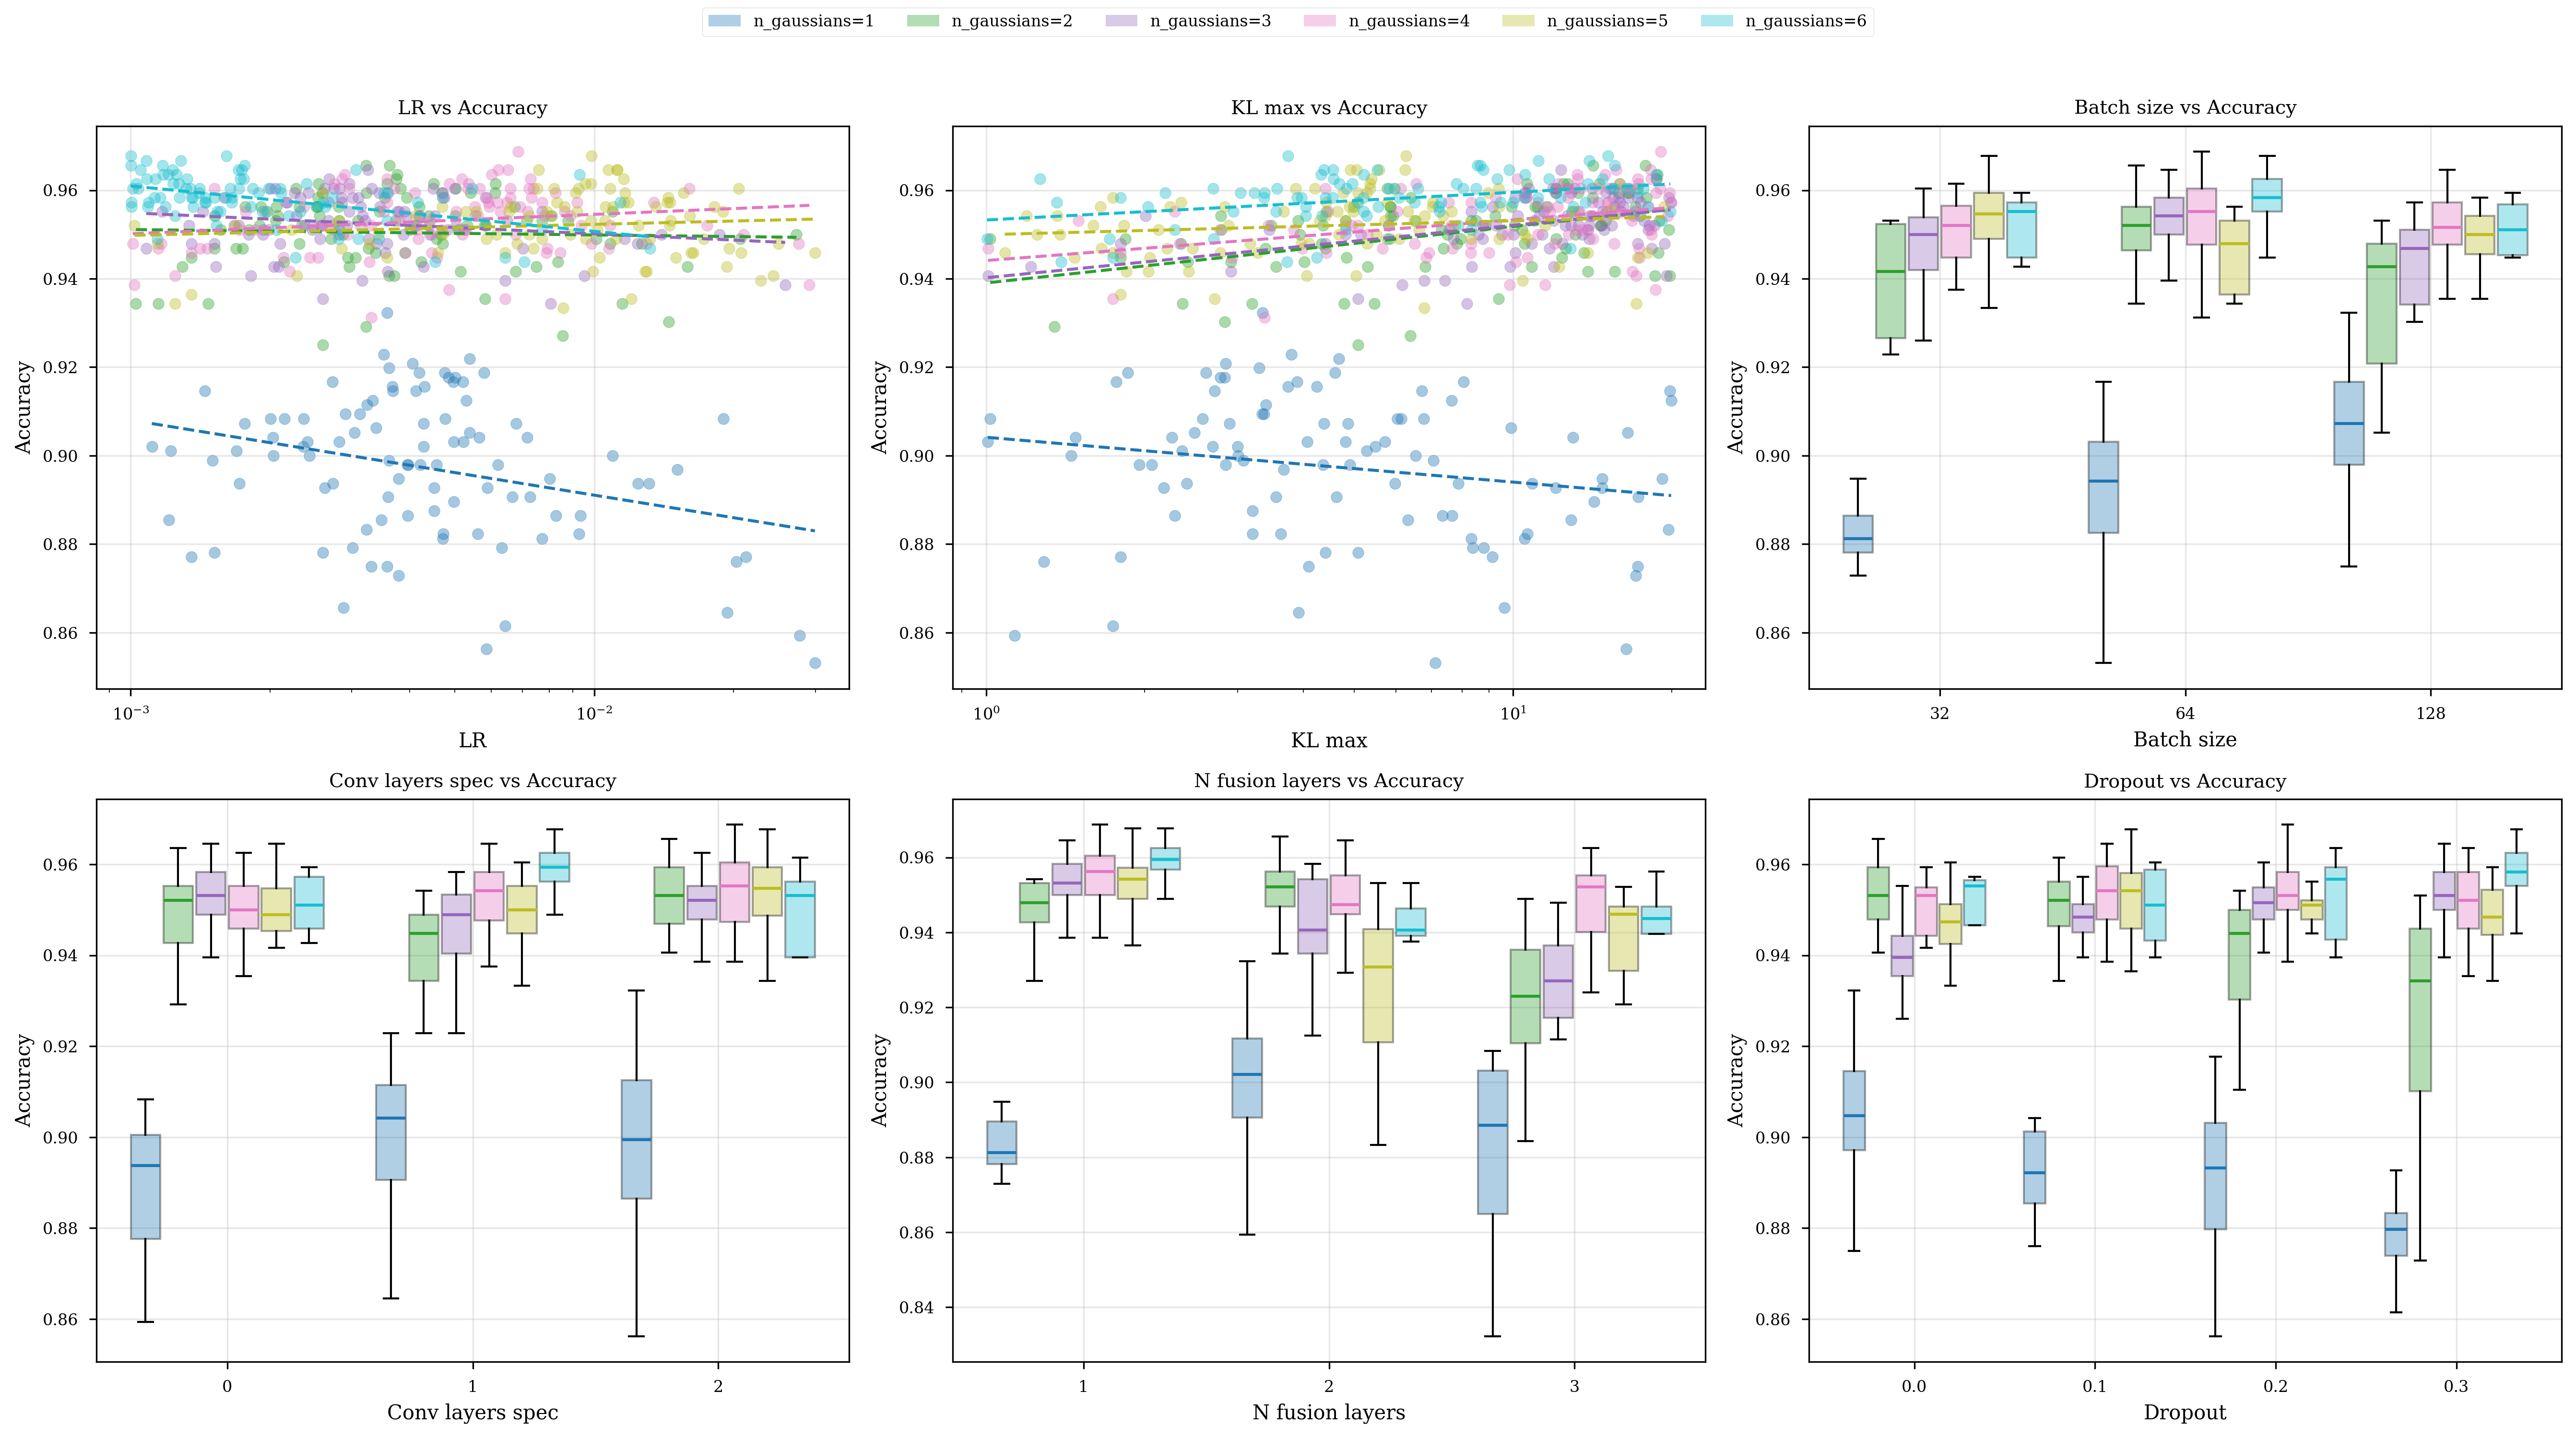

In [130]:
completed_studies = []
for study in studies:
    completed = study[study["state"] == "COMPLETE"].copy()
    completed["params_batch_size"] = completed["params_batch_size_exp"].apply(lambda x: 2 ** x)
    completed_studies.append(completed)

params = {
    "params_lr": ("LR", "continuous"),
    "params_kl_max": ("KL max", "continuous"),
    "params_batch_size": ("Batch size", "discrete"),
    "params_conv_layers_spec": ("Conv layers spec", "discrete"),
    "params_n_fusion_layers": ("N fusion layers", "discrete"),
    "params_fusion_dropout": ("Dropout", "discrete"),
}

study_labels = [f"n_gaussians={i+1}" for i in range(len(completed_studies))]
colors = plt.colormaps["tab10"](np.linspace(0, 1, len(completed_studies)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, (label, kind)) in zip(axes, params.items(), strict=False):
    if kind == "continuous":
        for i, completed in enumerate(completed_sties := completed_studies):
            q1, q3 = completed["value"].quantile([0.25, 0.75])
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr

            completed = completed[(completed["value"] >= lower) & (completed["value"] <= upper)]
            ax.scatter(completed[col], completed["value"], alpha=0.4, color=colors[i])

            x = np.log10(completed[col])
            z = np.polyfit(x, completed["value"], 1)
            p = np.poly1d(z)
            x_sorted = np.sort(x)
            ax.plot(10**x_sorted, p(x_sorted), color=colors[i], linewidth=1.5, linestyle="--")

        ax.set_xscale("log")
    else:
        all_labels = sorted({v for completed in completed_studies for v in completed[col].dropna().unique()})
        base_positions = np.arange(1, len(all_labels) + 1)
        width = 0.8 / len(completed_studies)

        for i, completed in enumerate(completed_studies):
            grouped = {k: grp["value"].values for k, grp in completed.groupby(col)}
            data = [grouped.get(v, np.array([np.nan])) for v in all_labels]
            positions = base_positions + (i - (len(completed_studies) - 1) / 2) * width
            bp = ax.boxplot(
                data,
                positions=positions,
                widths=width * 0.9,
                patch_artist=True,
                manage_ticks=False,
                showfliers=False,
            )

            for box in bp["boxes"]:
                box.set_facecolor(colors[i])
                box.set_alpha(0.35)

            for median in bp["medians"]:
                median.set_color(colors[i])
                median.set_linewidth(1.5)

        ax.set_xticks(base_positions)
        ax.set_xticklabels([str(v) for v in all_labels])

    ax.set_xlabel(label)
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{label} vs Accuracy")
    ax.grid(alpha=0.3)

legend_handles = [
    mpl.patches.Patch(facecolor=colors[i], alpha=0.35, label=study_labels[i]) # pyright: ignore[reportAttributeAccessIssue]
    for i in range(len(completed_studies))
]
fig.legend(handles=legend_handles, loc="upper center", ncol=len(completed_studies))
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.savefig(PLOTS_DIR / "hyperparameters_accuracy_gaussians_all.pdf")
plt.show()